# Problem 1

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng(seed=598)

n = 1000
p = 20

beta = np.array([2, -1, 0, 0.8, 0, -1.5, 1.2, 0, 0, 0.3, -0.7, 0, 1.8, 0, 0.5, 0, -1.2, 0, 0.4, 0])
X = rng.standard_normal(size=(n,  p))
epsilon = rng.standard_normal(p)
Y = X * beta + epsilon

print(beta.shape)
print(X.shape)
print(epsilon.shape)
print(Y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.8, 
    random_state=598,
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(20,)
(1000, 20)
(20,)
(1000, 20)
(200, 20)
(200, 20)
(800, 20)
(800, 20)


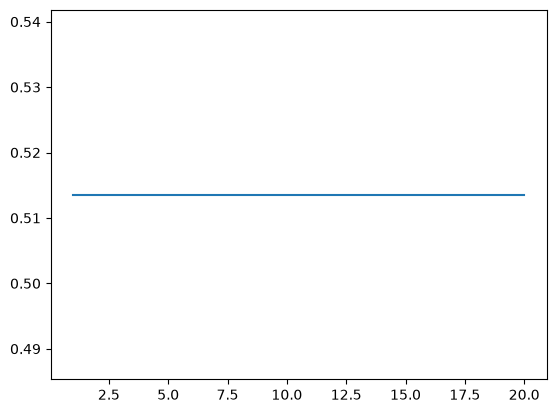

In [21]:
test_mses = []
model_sizes = range(1, X_train.shape[1] + 1)

for k in model_sizes:
    best_model_pipeline = Pipeline([
        ('sfs', SequentialFeatureSelector(
            estimator=LinearRegression(), 
            n_features_to_select=3, 
            direction='forward'
        )),
        ('regressor', LinearRegression())
    ])

    best_model_pipeline.fit(X_train, y_train)
    y_pred = best_model_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    test_mses.append(mse)

plt.plot(model_sizes, test_mses)